# Task 2: Yelp Polarity Sentiment Classification

This notebook summarizes my final Task 2 experiment. It uses the saved EDA, preprocessing summaries, training outputs, test metrics, statistical tests, and plots. It does not retrain any model.

Final model order:

1. Mean-Pooled Embedding Baseline
2. DPCNN
3. TextCNN


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

root = Path.cwd()
print("Project root:", root)


Project root: /mnt/data/task2_work/task2_sentiment/Rishitha_Gogineni


## Dataset and preprocessing

The dataset is Yelp Polarity. I kept the official test split separate. The training subset is used to build the vocabulary, which avoids validation or test leakage through vocabulary construction.

In [2]:
eda = json.loads((root / "outputs" / "eda_summary.json").read_text())
prep = json.loads((root / "data_processed" / "preprocessing_summary.json").read_text())

summary = pd.DataFrame({
    "Item": [
        "Original training reviews",
        "Test reviews",
        "Negative training reviews",
        "Positive training reviews",
        "Median review length (words)",
        "95th percentile review length",
        "Cleaned-empty reviews removed",
        "Final training reviews",
        "Validation reviews",
        "Vocabulary size",
        "Vocabulary coverage (%)",
        "Maximum sequence length"
    ],
    "Value": [
        eda["train_rows"],
        eda["test_rows"],
        eda["train_classes"]["negative_count"],
        eda["train_classes"]["positive_count"],
        eda["train_review_length_words"]["median"],
        eda["train_review_length_words"]["p95"],
        prep["cleaned_empty_reviews"],
        prep["train_reviews"],
        prep["validation_reviews"],
        prep["final_vocab_size"],
        round(prep["vocab_coverage_percent"], 2),
        prep["max_length"]
    ]
})
display(summary)


,Item,Value
0,Original training reviews,560000.00
1,Test reviews,38000.00
2,Negative training reviews,280000.00
3,Positive training reviews,280000.00
4,Median review length (words),97.00
5,95th percentile review length,372.00
6,Cleaned-empty reviews removed,28.00
7,Final training reviews,503974.00
8,Validation reviews,55998.00
9,Vocabulary size,30000.00


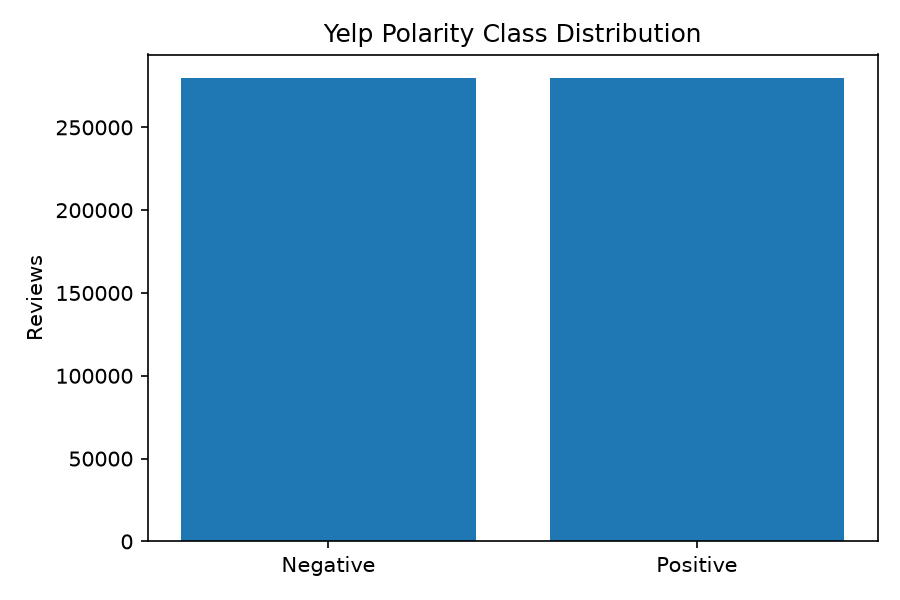

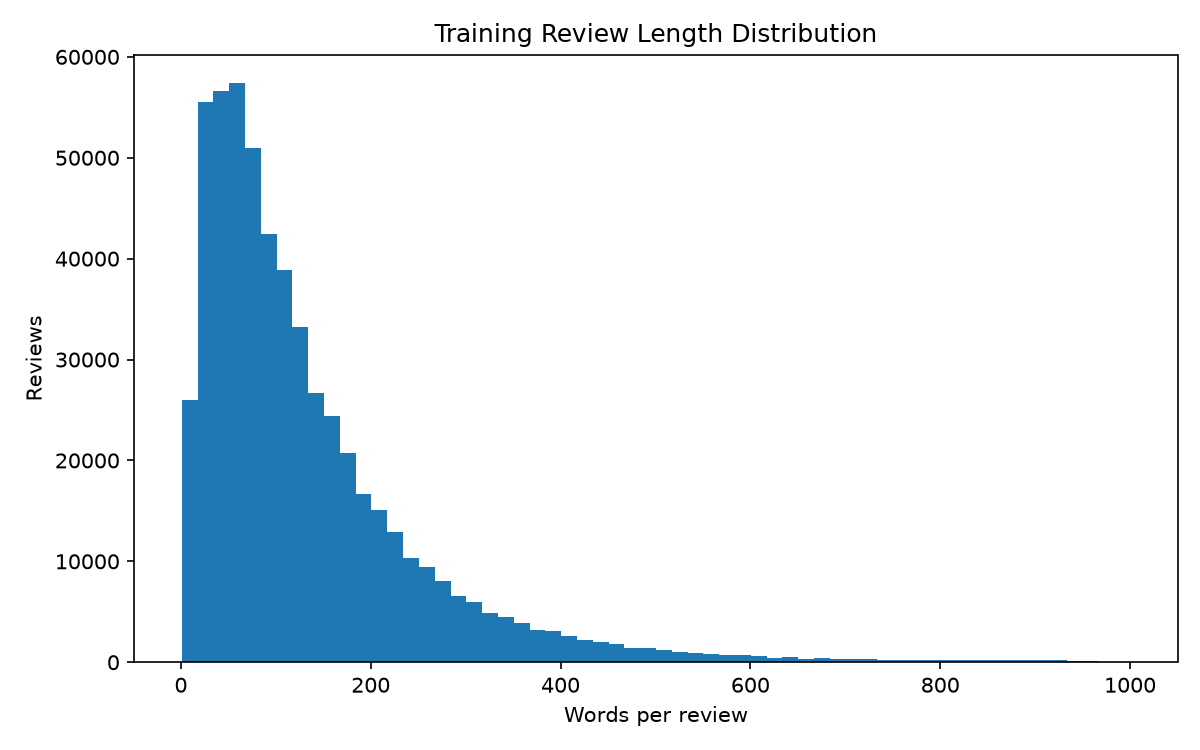

In [3]:
display(Image(filename=str(root / "outputs" / "plots" / "class_distribution.png")))
display(Image(filename=str(root / "outputs" / "plots" / "review_length_distribution.png")))


## Preprocessing choices

Text is lowercased, common contractions are expanded, URLs and unwanted special characters are removed, and whitespace is normalized. Negation words are kept. Stopword removal, stemming, and lemmatization are not used because they can remove useful sentiment and phrase information. The models use randomly initialized embeddings learned from the Yelp training data.

## Final models

### Model 1: Mean-Pooled Embedding Baseline

The baseline uses 128-dimensional learned embeddings, masked mean pooling, a 256-unit hidden layer, ReLU, dropout 0.30, and a binary output. It provides a simple reference without explicit phrase modeling.

### Model 2: DPCNN

DPCNN uses 200-dimensional embeddings, a 250-channel convolution, four residual convolution blocks with downsampling, global max pooling, dropout 0.25, and a binary output. The final run uses learning rate 0.0001 and gradient clipping at 1.0 because the initial setting was unstable.

### Model 3: TextCNN

TextCNN uses 200-dimensional embeddings and three Conv1D branches with kernel sizes 3, 4, and 5 and 128 filters per branch. Global max pooling combines the strongest phrase features before dropout and binary classification.

## Training behavior

The baseline reached its lowest validation loss at epoch 3. After that, training loss continued to decrease but validation loss started to rise slightly, so I kept the epoch 3 checkpoint.

DPCNN reached its lowest validation loss at epoch 2. Training accuracy continued to increase through epoch 5, but validation loss became higher after epoch 2. This was a sign that extra training was not improving generalization, so the epoch 2 checkpoint was used.

TextCNN reached its lowest validation loss at epoch 3. Its training loss kept decreasing in later epochs, while validation loss increased. I therefore used the epoch 3 checkpoint for the final test evaluation.

![Training and validation loss curves](../outputs/plots/training_validation_loss_curves.svg)

## Final test metrics

Both convolutional models improved over the mean-pooled baseline. TextCNN had the highest test accuracy and macro F1 at 95.15 percent. DPCNN was very close in accuracy and had the highest ROC-AUC and PR-AUC. The baseline had the lowest ECE, while DPCNN had the highest ECE, so DPCNN's probability estimates were less well calibrated.

In [4]:
comparison = pd.read_csv(root / "outputs" / "model_comparison.csv")
cols = [
    "model_label", "test_accuracy", "f1_macro", "roc_auc", "pr_auc",
    "mcc", "brier_score", "ece", "parameter_count", "training_time_seconds",
    "mean_training_examples_per_sec", "peak_training_memory_gb"
]
view = comparison[cols].copy()
view["test_accuracy"] = (view["test_accuracy"] * 100).round(2)
view["f1_macro"] = (view["f1_macro"] * 100).round(2)
view["training_time_seconds"] = (view["training_time_seconds"] / 60).round(2)
view = view.rename(columns={
    "model_label":"Model",
    "test_accuracy":"Accuracy (%)",
    "f1_macro":"Macro F1 (%)",
    "training_time_seconds":"Training time (min)",
    "mean_training_examples_per_sec":"Train examples/sec",
    "peak_training_memory_gb":"Peak training memory (GB)"
})
display(view)


,Model,Accuracy (%),Macro F1 (%),roc_auc,pr_auc,mcc,brier_score,ece,parameter_count,Training time (min),Train examples/sec,Peak training memory (GB)
0,Model 1 - Mean-Pooled Embedding Baseline,93.75,93.75,0.983716,0.983414,0.874967,0.046675,0.007754,3873281,11.01,3822.560,0.122
1,Model 2 - DPCNN,95.08,95.08,0.991085,0.991458,0.902454,0.037274,0.023384,7652501,23.93,1757.074,0.229
2,Model 3 - TextCNN,95.15,95.15,0.989159,0.989517,0.903001,0.037165,0.008029,6307969,16.78,2506.124,0.178


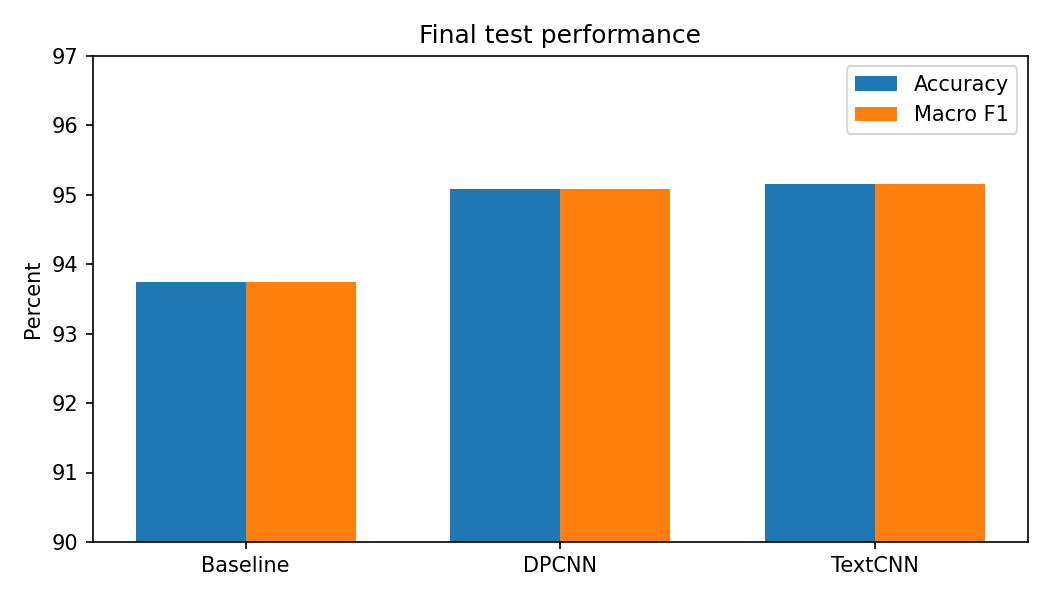

In [5]:
display(Image(filename=str(root / "outputs" / "plots" / "model_comparison_accuracy_f1.png")))


## Confidence intervals

The 95 percent bootstrap confidence intervals for accuracy and macro F1 are narrow for all three models because the test set contains 38,000 reviews. The two convolutional models have very similar intervals, while both are clearly above the baseline on these metrics.

In [6]:
ci = comparison[[
    "model_label", "accuracy_ci95_low", "accuracy_ci95_high",
    "macro_f1_ci95_low", "macro_f1_ci95_high", "mcc_ci95_low", "mcc_ci95_high"
]].copy()
for c in ["accuracy_ci95_low","accuracy_ci95_high","macro_f1_ci95_low","macro_f1_ci95_high"]:
    ci[c] = (ci[c] * 100).round(2)
display(ci)


,model_label,accuracy_ci95_low,accuracy_ci95_high,macro_f1_ci95_low,macro_f1_ci95_high,mcc_ci95_low,mcc_ci95_high
0,Model 1 - Mean-Pooled Embedding Baseline,93.50,93.98,93.50,93.98,0.870067,0.879555
1,Model 2 - DPCNN,94.88,95.29,94.88,95.28,0.898453,0.906466
2,Model 3 - TextCNN,94.92,95.35,94.92,95.35,0.898424,0.907053


## Paired McNemar tests

The baseline is compared with each experimental model using paired predictions on the same 38,000 test reviews. Both comparisons produced very small p-values, showing that the experimental models changed the error pattern significantly rather than giving only a small random difference on the test set.

In [7]:
mcnemar = pd.read_csv(root / "outputs" / "mcnemar_tests.csv")
display(mcnemar)


,comparison,baseline_only_correct,experimental_only_correct,discordant_pairs,exact_mcnemar_p_value,interpretation
0,Baseline vs DPCNN,935,1442,2377,2.052069e-25,Different error rates at alpha 0.05
1,Baseline vs TextCNN,693,1226,1919,2.319266e-34,Different error rates at alpha 0.05


## Slice robustness

Long reviews were harder than medium-length reviews for all three models. The baseline also had more difficulty with reviews containing negation. DPCNN and TextCNN reduced the error rate on these harder slices, but difficult long and mixed-sentiment reviews still remained.

In [8]:
slices = pd.read_csv(root / "outputs" / "slice_comparison.csv")
slice_view = slices.copy()
slice_view["macro_f1"] = (slice_view["macro_f1"] * 100).round(2)
slice_view["error_rate"] = (slice_view["error_rate"] * 100).round(2)
display(slice_view)


,model,slice,count,macro_f1,error_rate
0,Model 1 - Mean-Pooled Embedding Baseline,length_short_0_50,9037,93.59,6.14
1,Model 1 - Mean-Pooled Embedding Baseline,length_medium_51_200,21017,93.92,6.08
2,Model 1 - Mean-Pooled Embedding Baseline,length_long_201_plus,7946,92.78,6.83
3,Model 1 - Mean-Pooled Embedding Baseline,negation_present,27918,93.12,6.66
4,Model 1 - Mean-Pooled Embedding Baseline,negation_absent,10082,93.13,5.13
5,Model 2 - DPCNN,length_short_0_50,9037,94.62,5.19
6,Model 2 - DPCNN,length_medium_51_200,21017,95.36,4.63
7,Model 2 - DPCNN,length_long_201_plus,7946,94.23,5.36
8,Model 2 - DPCNN,negation_present,27918,94.96,4.83
9,Model 2 - DPCNN,negation_absent,10082,93.28,5.16


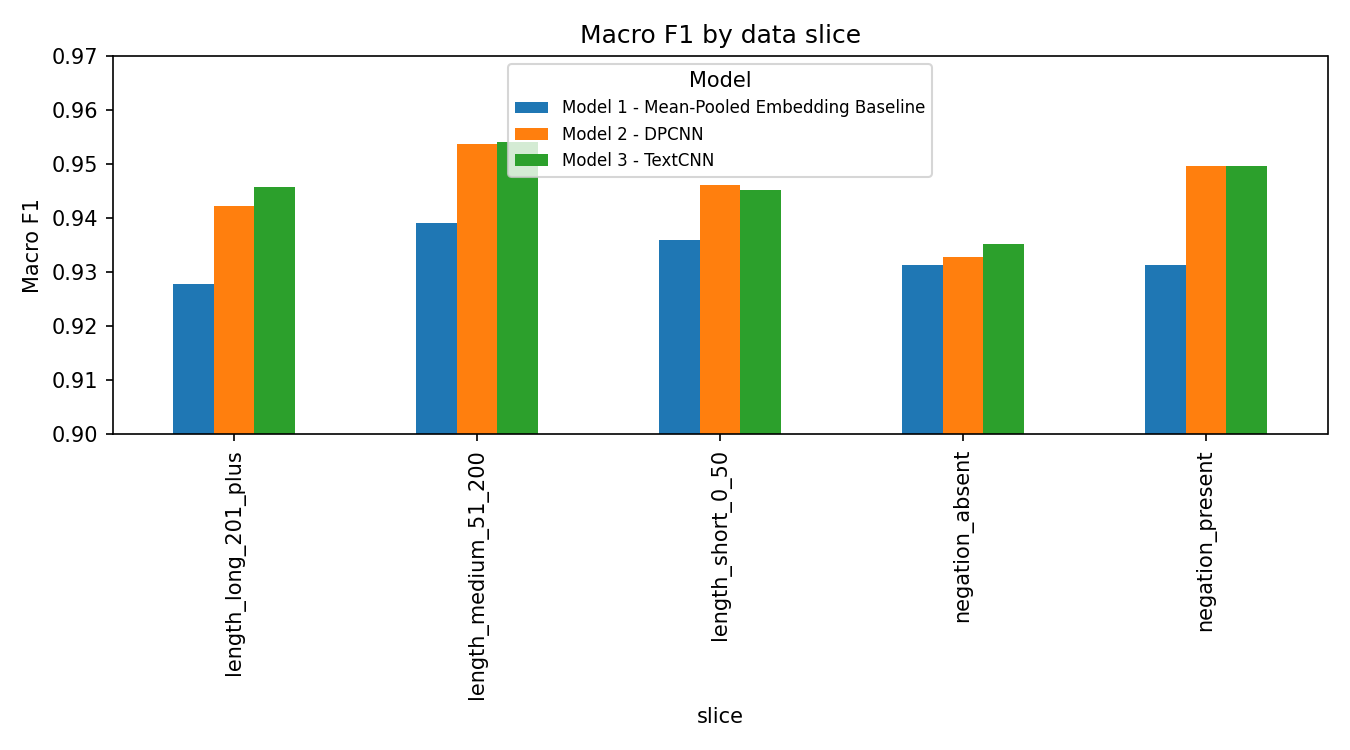

In [9]:
display(Image(filename=str(root / "outputs" / "plots" / "slice_macro_f1_comparison.png")))


## Error analysis

I used the final TextCNN for the required 20-case manual error review because it had the highest test accuracy. The selected errors include five confident false positives, five confident false negatives, five near-threshold errors, and five slice-specific failures.

In [10]:
errors = pd.read_csv(root / "outputs" / "error_analysis" / "textcnn_manual_error_review.csv")
print(errors["category"].value_counts())
display(errors[[
    "category", "test_index", "true_label", "predicted_label",
    "positive_probability", "error_type", "observation", "testable_fix"
]])


category
Confident false positive    5
Confident false negative    5
Near-threshold error        5
Slice-specific failure      5
Name: count, dtype: int64


,category,test_index,true_label,predicted_label,positive_probability,error_type,observation,testable_fix
0,Confident false positive,29330,0,1,0.999908,Possible label noise,The review is strongly positive from start to ...,"Audit or relabel ambiguous training examples, ..."
1,Confident false positive,17407,0,1,0.999611,Long mixed review and truncation,The review starts with a very positive earlier...,Use head-and-tail truncation or sentence-level...
2,Confident false positive,12495,0,1,0.999581,Mixed sentiment,"Positive food words dominate, while the negati...",Add aspect-aware pooling so food quality and v...
3,Confident false positive,22663,0,1,0.999314,Aspect conflict,"Food, service, and ambience are described posi...",Use sentence or aspect-level features instead ...
4,Confident false positive,35584,0,1,0.999212,Mixed pros and cons,The review contains strong positive phrases ab...,Train with sentence-level sentiment aggregatio...
5,Confident false negative,29494,1,0,0.000016,Update reversal,A strongly negative original review is followe...,Give more weight to explicit update sections o...
6,Confident false negative,30366,1,0,0.000044,Mixed overall rating,"The food and waiter are praised, but the birth...",Use aspect-level sentiment features and combin...
7,Confident false negative,30086,1,0,0.000058,Context and label ambiguity,The text reports that the business closed and ...,Flag low-agreement examples for review and use...
8,Confident false negative,29600,1,0,0.000089,Local negative phrase dominates,"The phrase ""Terrible joke, sorry"" is negative,...",Use wider context around sentiment words so is...
9,Confident false negative,22807,1,0,0.000099,Edited review conflict,"The opening edit says service improved, but mo...",Detect edited or updated sections and weight t...


## Observations

The mean-pooled baseline is fast and well calibrated, but averaging removes word order and phrase structure. TextCNN gives the highest test accuracy and macro F1 while keeping the model relatively compact. DPCNN gives the highest ROC-AUC and PR-AUC, but it is slower and its ECE is higher, so its probabilities are less well calibrated.

Long mixed reviews are difficult for every model. Several reviewed errors contain an early positive section followed by a negative conclusion, or an edited review where the sentiment changes over time. With a fixed 384-token limit, important final context can be lost. Sarcasm, aspect conflict, and possible label noise are other recurring failure types.

Possible next steps include head-and-tail truncation, hierarchical sentence pooling, aspect-aware sentiment modeling, label auditing, and post-training calibration.

## Hardware and reproducibility

In [11]:
print((root / "manifest" / "environment.txt").read_text())
print("Checkpoint manifest:")
display(pd.read_csv(root / "manifest" / "checkpoint_manifest.csv"))


python=3.11.9
platform=Windows-10-10.0.22631-SP0
cpu=Intel64 Family 6 Model 165 Stepping 2, GenuineIntel
pytorch=2.7.1+cu118
cuda_available=True
pytorch_cuda=11.8
gpu=NVIDIA GeForce RTX 2070 Super with Max-Q Design
gpu_memory_gb=8.00

Checkpoint manifest:


,model_label,run_id,checkpoint,best_epoch,validation_loss,validation_accuracy,test_metrics_file,prediction_file,raw_log
0,Model 1 - Mean-Pooled Embedding Baseline,20260926_130146,checkpoints/baseline_20260926_130146_best.pt,3,0.171307,0.933426,outputs/baseline_20260926_130146_test_metrics.csv,outputs/predictions/baseline_20260926_130146_p...,logs/raw/baseline_20260926_130146.log
1,Model 2 - DPCNN,20260926_152502,checkpoints/dpcnn_20260926_152502_best.pt,2,0.134362,0.948570,outputs/dpcnn_20260926_152502_test_metrics.csv,outputs/predictions/dpcnn_20260926_152502_pred...,logs/raw/dpcnn_20260926_152502.log
2,Model 3 - TextCNN,20260926_133806,checkpoints/textcnn_20260926_133806_best.pt,3,0.137209,0.949391,outputs/textcnn_20260926_133806_test_metrics.csv,outputs/predictions/textcnn_20260926_133806_pr...,logs/raw/textcnn_20260926_133806.log
